In [1]:
# import packages
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

## dask bc things are so slow

In [16]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='10GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=10GB',
        account='XX',
        walltime='02:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [17]:
cluster, client = get_ClusterClient()
#cluster.scale(20) 
cluster.adapt(minimum=0, maximum=20)

In [18]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.95:46715,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [75]:
# Close out Dask Cluster and release workers:
# NOTE:  only run this cell to terminate Dask Cluster!
cluster.close()
client.close()

## e3sm functions

In [2]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

In [45]:
# combine piControl 1 year runs (50 files) into a single 500 year file
# do for various monthly ocean and atmosphere variables
ds_temp_ocn = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_activeTracers_temperature.*.nc'
)

/glade/derecho/scratch/ewisinski/tmp/ipykernel_46391/3209405961.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_temp_ocn = xr.open_mfdataset(


In [46]:
# print variables to check dimensions
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * time                                       (time) object 48kB 0001-02-01 ...
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [47]:
# fix start time
ds_temp_ocn = ds_temp_ocn.assign_coords(time=ds_temp_ocn['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))

In [48]:
ds_temp_ocn

<xarray.Dataset> Size: 96GB
Dimensions:                                    (time: 6000, lat: 180, nbnd: 2,
                                                lon: 360, nVertLevels: 60)
Coordinates:
  * time                                       (time) object 48kB 0001-01-01 ...
  * lat                                        (lat) float64 1kB -89.5 ... 89.5
  * lon                                        (lon) float64 3kB 0.5 ... 359.5
Dimensions without coordinates: nbnd, nVertLevels
Data variables:
    lat_bnds                                   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds                                   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                                         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                                       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_activeTracers_temperature  (time, nVertLevels, lat, lon) float32 93GB dask.array<chunksize=(120, 60, 180, 360), meta=np.ndarray>
    time_bnds                                  (time, nbnd) object 96kB dask.array<chunksize=(120, 2), meta=np.ndarray>
Attributes: (12/756)
    title:                                                        MPAS-Ocean ...
    source:                                                       CAM
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         b.e21.B1850...
    ...                                                           ...
    host:                                                         cheyenne4
    initial_file:                                                 b.e20.B1850...
    topography_file:                                              /glade/p/ce...
    model_doi_url:                                                https://doi...
    time_period_freq:                                             month_1
    history_of_appended_files:                                    Fri Apr 28 ...

In [49]:
print(ds_temp_ocn['timeMonthly_avg_activeTracers_temperature'].shape) 

(6000, 60, 180, 360)


In [50]:
# grab sst variable
temp = ds_temp_ocn['timeMonthly_avg_activeTracers_temperature']

In [51]:
# grab sea surface value
temp_surface = temp[:, 0]

In [52]:
temp_surface

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 180,
                                                               lon: 360)> Size: 2GB
dask.array<getitem, shape=(6000, 180, 360), dtype=float32, chunksize=(120, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [53]:
# climatology
clim = temp_surface.groupby("time.month").mean("time")

In [54]:
# sst anomalies
ssta = temp_surface.groupby("time.month") - clim

In [55]:
# latitude/longitude slice
tpac = ssta.sel(lat=slice(-20,20), lon=slice(120,280))

In [56]:
tpac

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 40, lon: 160)> Size: 154MB
dask.array<getitem, shape=(6000, 40, 160), dtype=float32, chunksize=(12, 40, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
  * lat      (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 16.5 17.5 18.5 19.5
  * lon      (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 277.5 278.5 279.5
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

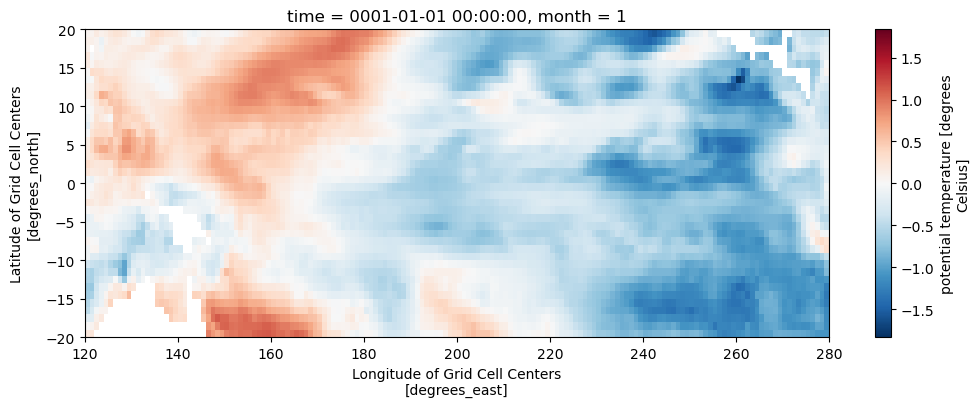

In [57]:
# sanity check
tpac[0].plot.pcolormesh(figsize=(12,4))

## remove enso

In [58]:
# nino3.4 spatial mean
nino34 = ssta.sel(lat=slice(-5,5), lon=slice(190,240)).mean(("lat","lon"))

In [59]:
nino34

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000)> Size: 24kB
dask.array<mean_agg-aggregate, shape=(6000,), dtype=float32, chunksize=(12,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [60]:
# regress nino3.4 out
beta = xr.cov(tpac, nino34, dim="time") / nino34.var("time")

tpac_noenso = tpac - beta * nino34

In [71]:
# check if the filter actually did anything
print(tpac_noenso.std("time").mean().values)  # before filter
print(tpac_clean.std("time").mean().values)   # after filter
# the second should be much smaller

0.4604974022281227
0.1406205368002428


## low pass filter (6 years)

In [61]:
# minimum window to preserve edges
tpac_lp = tpac_noenso.rolling(time=72, center=True, min_periods=72).mean()

In [62]:
tpac_lp

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 40, lon: 160)> Size: 307MB
dask.array<getitem, shape=(6000, 40, 160), dtype=float64, chunksize=(131, 40, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
  * lat      (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 16.5 17.5 18.5 19.5
  * lon      (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 277.5 278.5 279.5
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [63]:
# for land pixels
mask = tpac_lp.notnull().all("time")

In [64]:
# dont drop land pixels
tpac_clean = tpac_lp.where(mask, drop=False)

In [65]:
tpac_clean

<xarray.DataArray 'timeMonthly_avg_activeTracers_temperature' (time: 6000,
                                                               lat: 40, lon: 160)> Size: 307MB
dask.array<where, shape=(6000, 40, 160), dtype=float64, chunksize=(131, 40, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
  * lat      (lat) float64 320B -19.5 -18.5 -17.5 -16.5 ... 16.5 17.5 18.5 19.5
  * lon      (lon) float64 1kB 120.5 121.5 122.5 123.5 ... 277.5 278.5 279.5
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      potential temperature
    units:          degrees Celsius
    cell_measures:  area: area
    cell_methods:   time: mean

In [ ]:
# check if the filter actually did anything
print(tpac_noenso.std("time").mean().values)  # before filter
print(tpac_clean.std("time").mean().values)   # after filter
# the second should be much smaller

In [66]:
weights = np.cos(np.deg2rad(tpac_clean.lat))
tpdv = tpac_clean.weighted(weights).mean(["lat", "lon"])

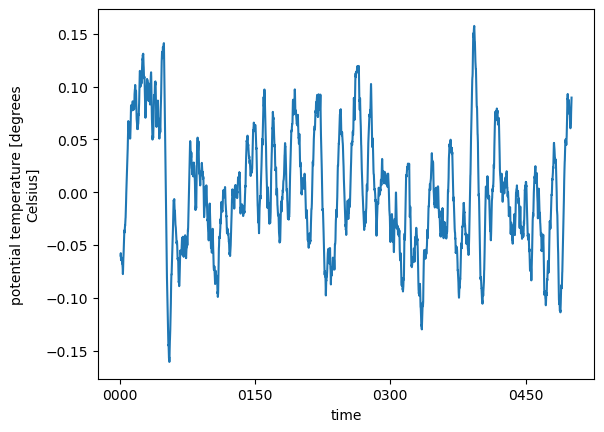

In [68]:
tpdv.plot()

In [72]:
tpdv.to_netcdf('tpdv_v1.nc')

[[-0.01430057  0.00751556         nan ...  0.14735534  0.1527488
   0.15996865]
 [-0.03694682 -0.03011945  0.00948638 ...  0.14276275  0.14431796
   0.14519616]
 [-0.00579259 -0.03164183  0.01650444 ...  0.13806296  0.1436178
   0.1482645 ]
 ...
 [-0.02552486         nan -0.07063626 ...  0.02078344  0.02444959
   0.02680057]
 [-0.01478784 -0.02677223 -0.07088752 ...  0.03124989  0.03127337
   0.0320013 ]
 [-0.03157451 -0.06485821 -0.06332658 ...  0.03507636  0.03648774
   0.03715628]]


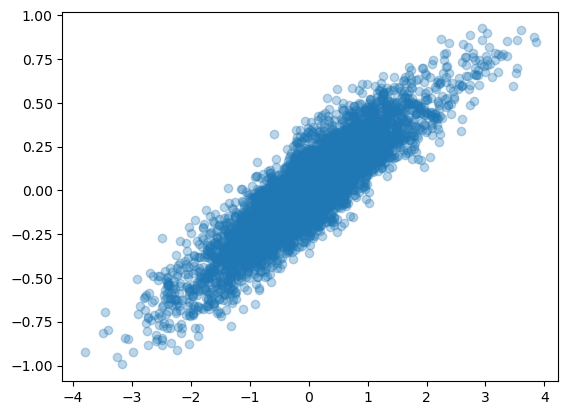

In [73]:
# sanity checks
# 1. how much variance did ENSO removal actually explain?
print(beta.values)  # does this look reasonable?

# 2. plot nino34 vs tpac mean to see the regression
plt.scatter(nino34.values, tpac.mean(["lat","lon"]).values, alpha=0.3)

In [ ]:
# more sanity checks
print(beta.min().values, beta.max().values)

beta.plot(figsize=(12, 4))